# Cradiovascular Disease Detection using Deep Learning

## Brief Overview

The goal of this project is to detect cardiovascular abnormalities from ECG images using deep learning.
A Convolutional Neural Network (CNN) is trained to classify ECG images into four medical conditions:

* Abnormal Heartbeat
* History of Myocardial Infarction
* Myocardial Infarction
* Normal Heart Condition

Datset used: https://www.kaggle.com/datasets/jayaprakashpondy/ecgimages and the folders are renamed for simplicity as follow:
* abnormal
* history_mi
* mi
* normal

# Importing Libraries and GPU Check

In [1]:
# Importing necessary libraries

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

2026-03-04 18:00:06.336684: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Quick check if my GPU is being used

import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Building Model

In [3]:
# Defining path directories

data_dir = "../dataset/ecg_images"

IMG_SIZE = (128,256)
BATCH_SIZE = 16

In [4]:
# Data Preprocessing and Normalisation
# Image Generator w/ split

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [5]:
# Loading Training Data

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

Found 745 images belonging to 4 classes.


In [6]:
# Loading Validation Data

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 183 images belonging to 4 classes.


In [7]:
# Confirming Classes

print(train_data.class_indices)
print(train_data.samples)
print(val_data.samples)

{'abnormal': 0, 'history_mi': 1, 'mi': 2, 'normal': 3}
745
183


In [8]:
# Buiilding CNN Model

model = models.Sequential([

    layers.Conv2D(32,(3,3),activation="relu",input_shape=(128,256,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(train_data.num_classes,activation="softmax")

])

/home/cyrax/miniconda3/envs/deeplearning/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1772647215.813829   51155 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2240 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


In [9]:
# Compiling Model

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

[0. 0. 1. 0.]


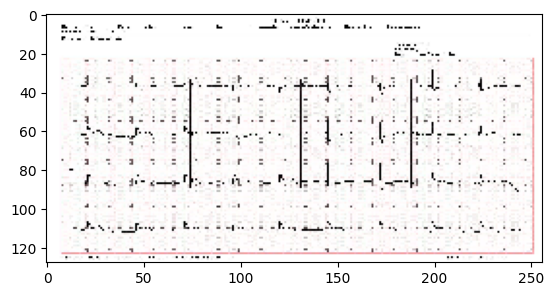

In [10]:
# Quickly viewing our batch

import matplotlib.pyplot as plt

x_batch, y_batch = next(train_data)

plt.imshow(x_batch[0])
print(y_batch[0])
plt.show()

In [11]:
x_batch, y_batch = next(train_data)

print(x_batch.min(), x_batch.max())

0.0 1.0


In [12]:
# Training Model

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15


2026-03-04 18:00:19.920816: I external/local_xla/xla/service/service.cc:163] XLA service 0x736508006f50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-04 18:00:19.921060: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1650 Ti, Compute Capability 7.5
2026-03-04 18:00:19.990836: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-04 18:00:20.397763: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-03-04 18:00:21.073894: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,32,126,254]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,3,128,256]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="

 1/47 ━━━━━━━━━━━━━━━━━━━━ 5:58 8s/step - accuracy: 0.1875 - loss: 1.3872

I0000 00:00:1772647226.008844   54364 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


38/47 ━━━━━━━━━━━━━━━━━━━━ 2s 226ms/step - accuracy: 0.2827 - loss: 1.5685

2026-03-04 18:00:35.045166: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[9,32,126,254]{3,2,1,0}, u8[0]{0}) custom-call(f32[9,3,128,256]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-04 18:00:35.124166: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[9,64,61,125]{3,2,1,0}, u8[0]{0}) custom-call(f32[9,32,63,127]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationF

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.2853 - loss: 1.5445

2026-03-04 18:00:41.928416: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,32,126,254]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,3,128,256]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-04 18:00:42.029421: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[16,64,61,125]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,32,63,127]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivat

47/47 ━━━━━━━━━━━━━━━━━━━━ 31s 512ms/step - accuracy: 0.2886 - loss: 1.4399 - val_accuracy: 0.3060 - val_loss: 1.3756
Epoch 2/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 264ms/step - accuracy: 0.2980 - loss: 1.3793 - val_accuracy: 0.3060 - val_loss: 1.3803
Epoch 3/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 257ms/step - accuracy: 0.2993 - loss: 1.3794 - val_accuracy: 0.3060 - val_loss: 1.3720
Epoch 4/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 337ms/step - accuracy: 0.3141 - loss: 1.3633 - val_accuracy: 0.4590 - val_loss: 1.3171
Epoch 5/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 252ms/step - accuracy: 0.4523 - loss: 1.1973 - val_accuracy: 0.5902 - val_loss: 0.8720
Epoch 6/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 259ms/step - accuracy: 0.6698 - loss: 0.8155 - val_accuracy: 0.8470 - val_loss: 0.5702
Epoch 7/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 337ms/step - accuracy: 0.8268 - loss: 0.4887 - val_accuracy: 0.8907 - val_loss: 0.3424
Epoch 8/15
47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 249ms/step - accuracy: 0.8846 - loss: 0.3079 - val_accuracy: 0.929

# Model Evaluation

In [13]:
model.evaluate(val_data)

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 210ms/step - accuracy: 0.9727 - loss: 0.0655


[0.06552127003669739, 0.9726775884628296]

## Confusion Matrix

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 198ms/step


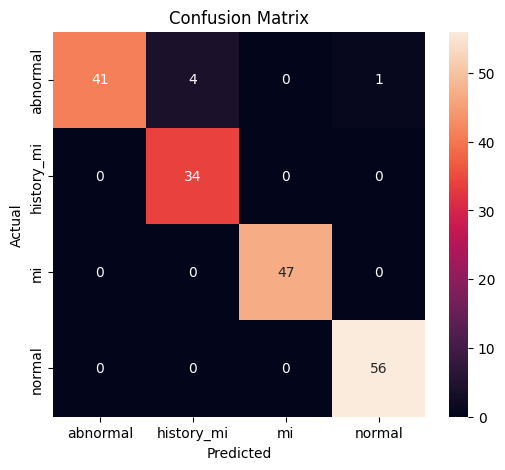

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred = model.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_data.classes

# cm = confusion_matrix(y_true, y_pred_classes)
# print(cm)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=val_data.class_indices.keys(),
            yticklabels=val_data.class_indices.keys())

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Classification Report

In [16]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=list(val_data.class_indices.keys())
))

              precision    recall  f1-score   support

    abnormal       1.00      0.89      0.94        46
  history_mi       0.89      1.00      0.94        34
          mi       1.00      1.00      1.00        47
      normal       0.98      1.00      0.99        56

    accuracy                           0.97       183
   macro avg       0.97      0.97      0.97       183
weighted avg       0.98      0.97      0.97       183



# Exporting our Model

In [17]:
model.save('../model/cnn_model.h5')